In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/smart-farming-sensor-data-for-yield-prediction/Smart_Farming_Crop_Yield_2024.csv


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [3]:
# Step 1: Load the dataset
print("Step 1: Loading the dataset...")
# Replace 'farm_data.csv' with your actual filename
df=pd.read_csv("/kaggle/input/smart-farming-sensor-data-for-yield-prediction/Smart_Farming_Crop_Yield_2024.csv")
print(f"Dataset loaded with {df.shape[0]} rows and {df.shape[1]} columns")

Step 1: Loading the dataset...
Dataset loaded with 500 rows and 22 columns


In [4]:
# Step 2: Explore the dataset
print("\nStep 2: Exploring the dataset...")
print("First 5 rows of the dataset:")
print(df.head())

print("\nDataset information:")
print(df.info())

print("\nStatistical summary:")
print(df.describe())

print("\nChecking for missing values:")
print(df.isnull().sum())


Step 2: Exploring the dataset...
First 5 rows of the dataset:
    farm_id       region crop_type  soil_moisture_%  soil_pH  temperature_C  \
0  FARM0001  North India     Wheat            35.95     5.99          17.79   
1  FARM0002    South USA   Soybean            19.74     7.24          30.18   
2  FARM0003    South USA     Wheat            29.32     7.16          27.37   
3  FARM0004  Central USA     Maize            17.33     6.03          33.73   
4  FARM0005  Central USA    Cotton            19.37     5.92          33.86   

   rainfall_mm  humidity_%  sunlight_hours irrigation_type  ... sowing_date  \
0        75.62       77.03            7.27             NaN  ...  2024-01-08   
1        89.91       61.13            5.67       Sprinkler  ...  2024-02-04   
2       265.43       68.87            8.23            Drip  ...  2024-02-03   
3       212.01       70.46            5.03       Sprinkler  ...  2024-02-21   
4       269.09       55.73            7.93             NaN  ...  20

In [5]:
# Step 3: Data preprocessing
print("\nStep 3: Data preprocessing...")
# Convert date columns to datetime format
df['sowing_date'] = pd.to_datetime(df['sowing_date'])
df['harvest_date'] = pd.to_datetime(df['harvest_date'])
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Verify total_days calculation
df['calculated_days'] = (df['harvest_date'] - df['sowing_date']).dt.days
print("Checking if calculated_days matches total_days:")
print((df['calculated_days'] == df['total_days']).value_counts())

# If there are discrepancies, use calculated_days
if not (df['calculated_days'] == df['total_days']).all():
    print("Some discrepancies found, using calculated values")
    df['total_days'] = df['calculated_days']
df.drop('calculated_days', axis=1, inplace=True)


Step 3: Data preprocessing...
Checking if calculated_days matches total_days:
True    500
Name: count, dtype: int64



Step 4: Performing exploratory data analysis...


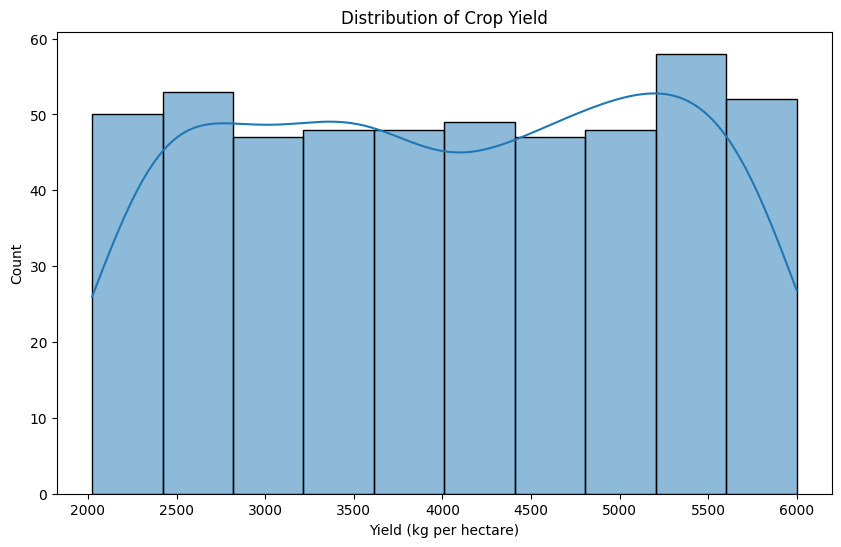

Yield distribution plot saved as 'yield_distribution.png'


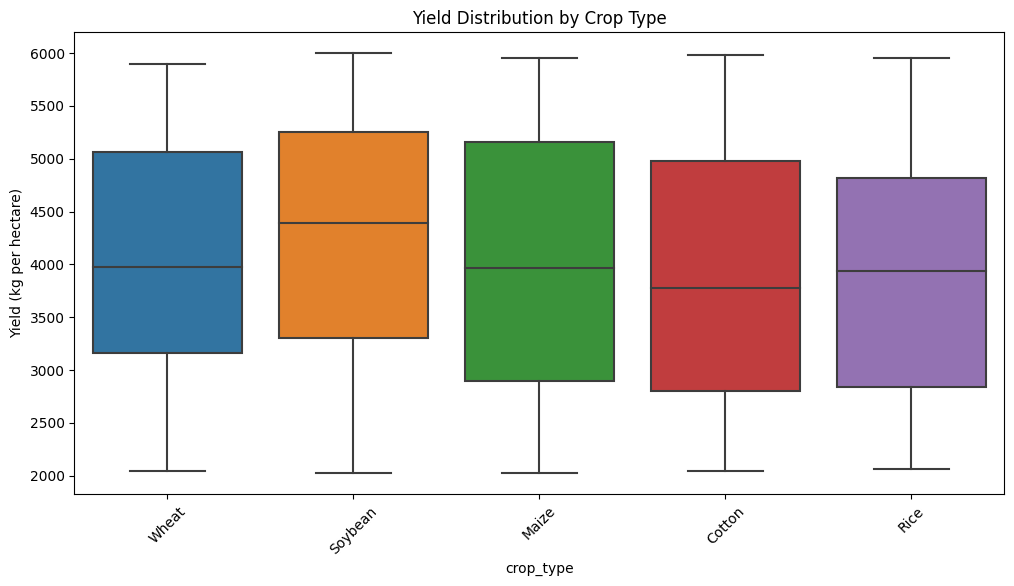

Yield by crop type plot saved as 'yield_by_crop.png'


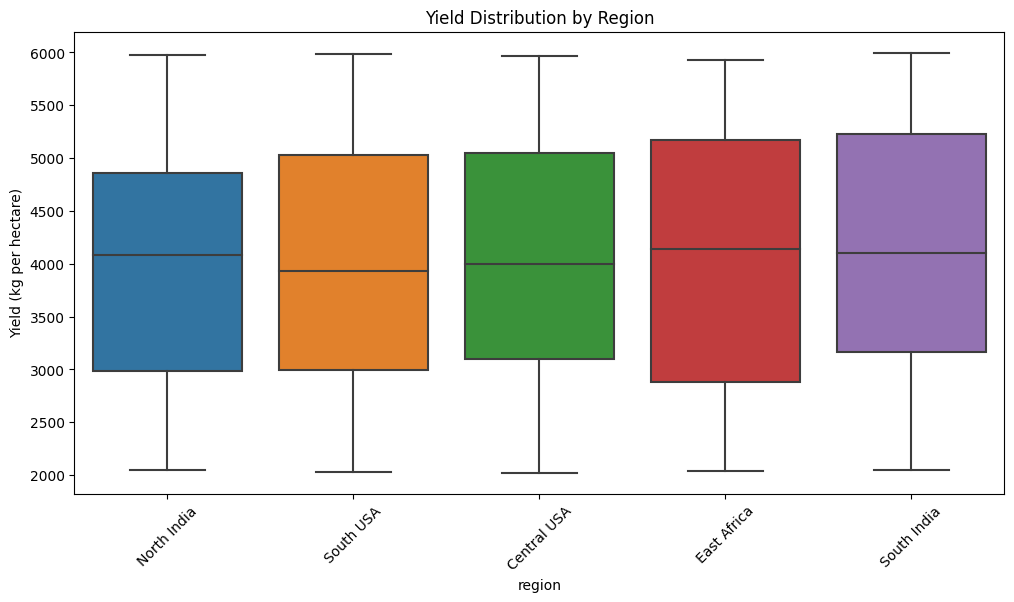

Yield by region plot saved as 'yield_by_region.png'


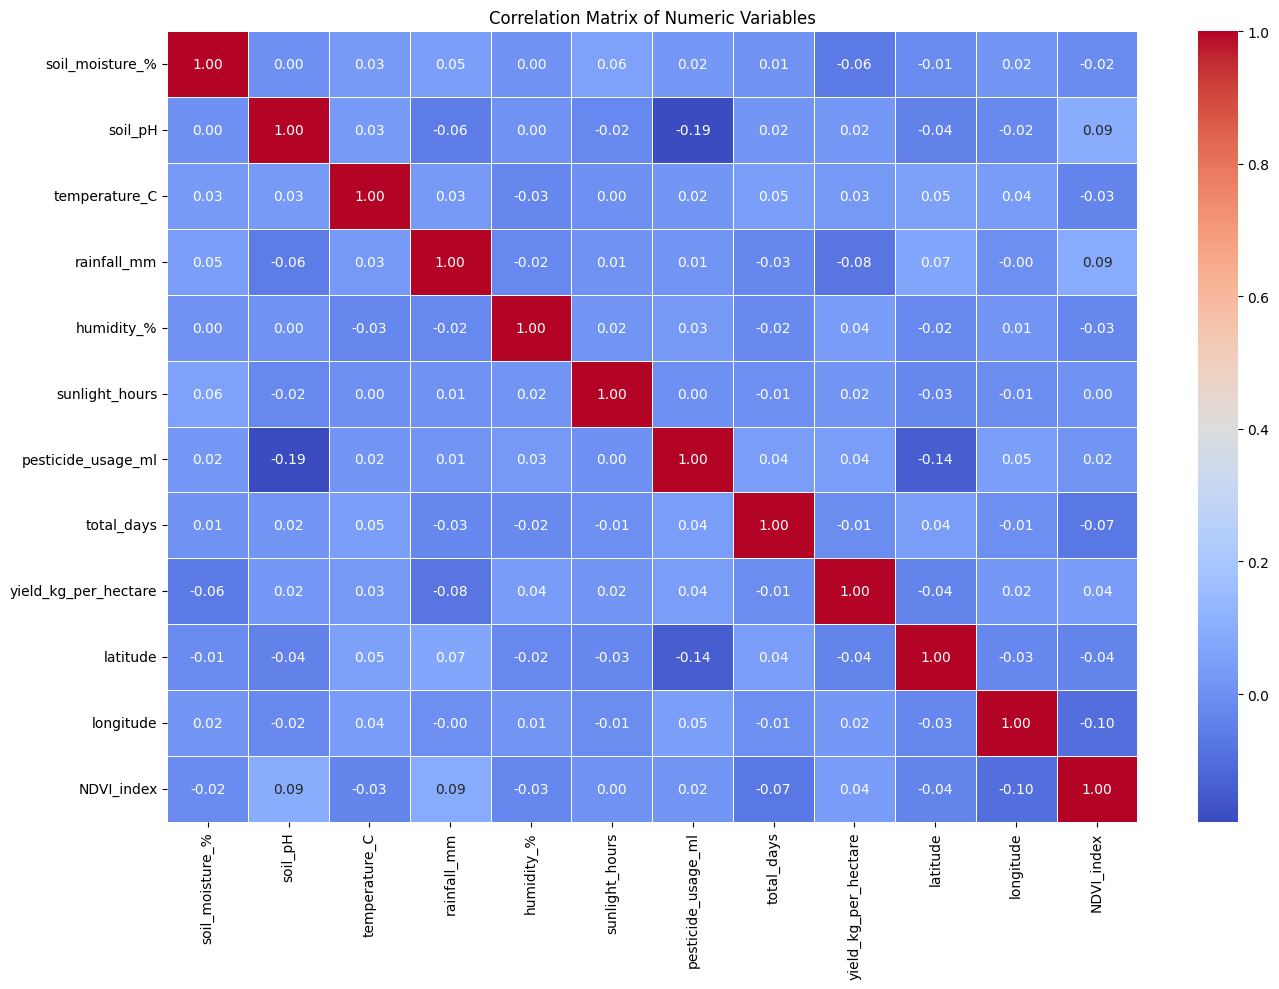

Correlation matrix saved as 'correlation_matrix.png'


In [6]:

# Step 4: Exploratory Data Analysis (EDA)
print("\nStep 4: Performing exploratory data analysis...")

# Analyze yield distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['yield_kg_per_hectare'], kde=True)
plt.title('Distribution of Crop Yield')
plt.xlabel('Yield (kg per hectare)')
plt.show()
print("Yield distribution plot saved as 'yield_distribution.png'")

# Yield by crop type
plt.figure(figsize=(12, 6))
sns.boxplot(x='crop_type', y='yield_kg_per_hectare', data=df)
plt.title('Yield Distribution by Crop Type')
plt.ylabel('Yield (kg per hectare)')
plt.xticks(rotation=45)
plt.show()
print("Yield by crop type plot saved as 'yield_by_crop.png'")

# Yield by region
plt.figure(figsize=(12, 6))
sns.boxplot(x='region', y='yield_kg_per_hectare', data=df)
plt.title('Yield Distribution by Region')
plt.ylabel('Yield (kg per hectare)')
plt.xticks(rotation=45)
plt.show()
print("Yield by region plot saved as 'yield_by_region.png'")

# Correlation analysis
plt.figure(figsize=(14, 10))
numeric_df = df.select_dtypes(include=[np.number])
correlation = numeric_df.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', linewidths=0.5, fmt=".2f")
plt.title('Correlation Matrix of Numeric Variables')
plt.tight_layout()
plt.show()
print("Correlation matrix saved as 'correlation_matrix.png'")


Step 5: Analyzing environmental factors vs yield...


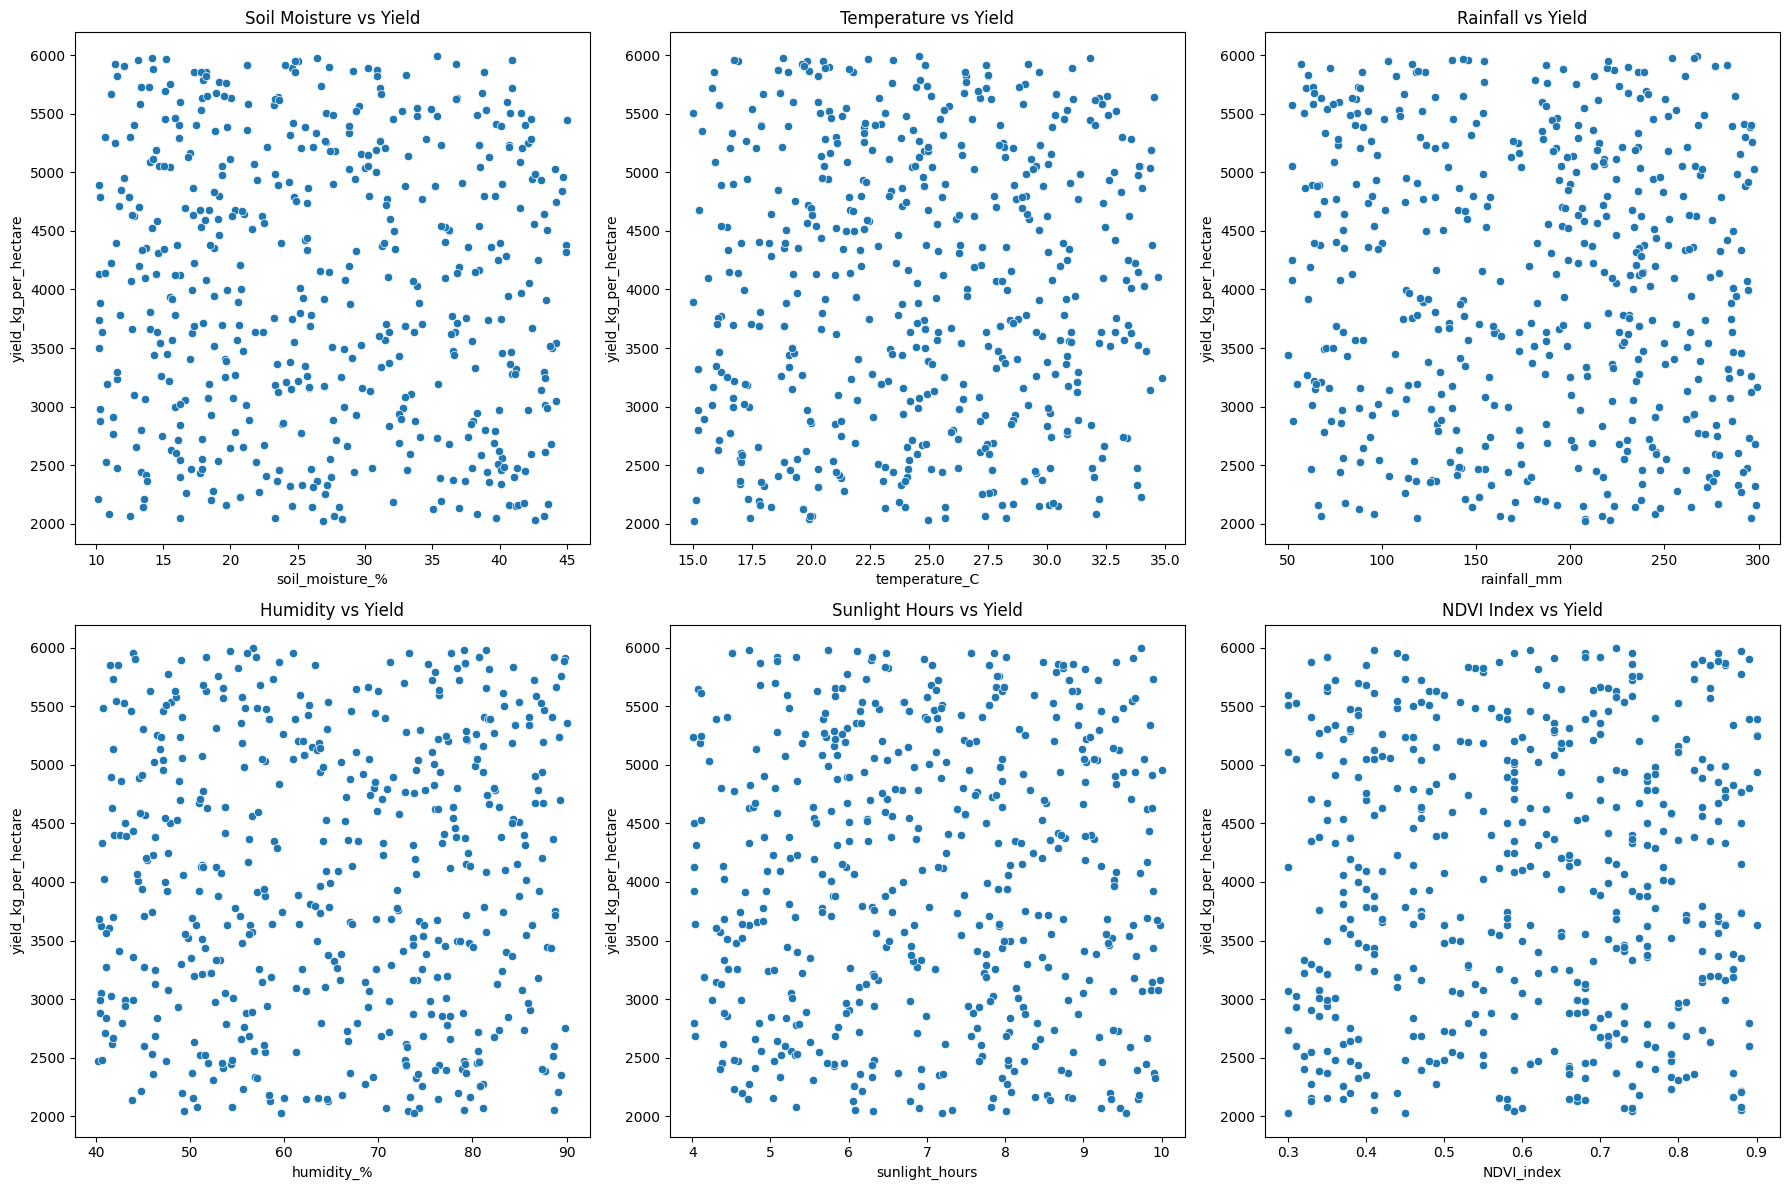

Environmental factors analysis saved as 'environmental_factors.png'


In [7]:
# Step 5: Analyze relationship between environmental factors and yield
print("\nStep 5: Analyzing environmental factors vs yield...")

# Create a figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Plot relationships
sns.scatterplot(x='soil_moisture_%', y='yield_kg_per_hectare', data=df, ax=axes[0])
axes[0].set_title('Soil Moisture vs Yield')

sns.scatterplot(x='temperature_C', y='yield_kg_per_hectare', data=df, ax=axes[1])
axes[1].set_title('Temperature vs Yield')

sns.scatterplot(x='rainfall_mm', y='yield_kg_per_hectare', data=df, ax=axes[2])
axes[2].set_title('Rainfall vs Yield')

sns.scatterplot(x='humidity_%', y='yield_kg_per_hectare', data=df, ax=axes[3])
axes[3].set_title('Humidity vs Yield')

sns.scatterplot(x='sunlight_hours', y='yield_kg_per_hectare', data=df, ax=axes[4])
axes[4].set_title('Sunlight Hours vs Yield')

sns.scatterplot(x='NDVI_index', y='yield_kg_per_hectare', data=df, ax=axes[5])
axes[5].set_title('NDVI Index vs Yield')

plt.tight_layout()
plt.show()
print("Environmental factors analysis saved as 'environmental_factors.png'")



Step 6: Analyzing impact of irrigation and fertilizer types...
Yield by irrigation type saved as 'yield_by_irrigation.png'


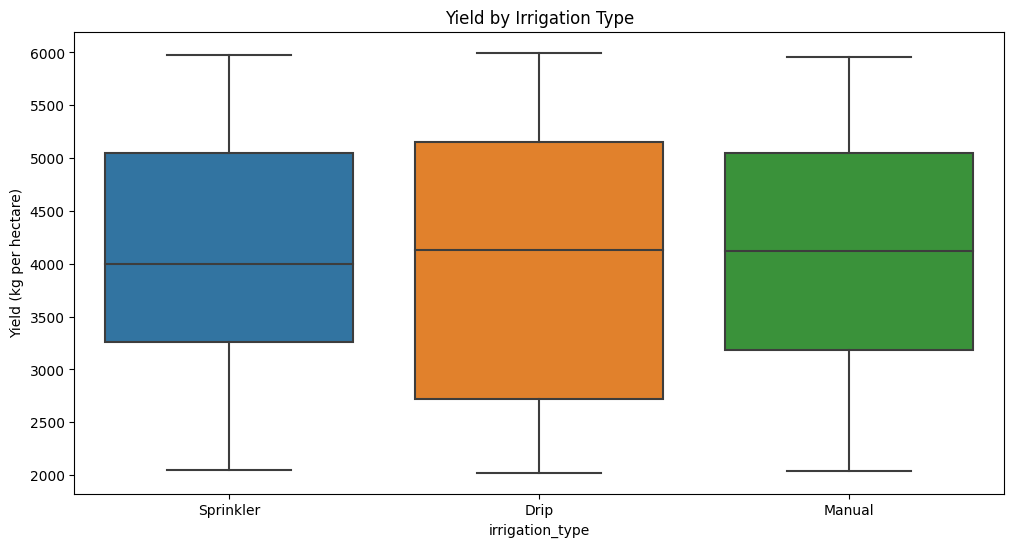

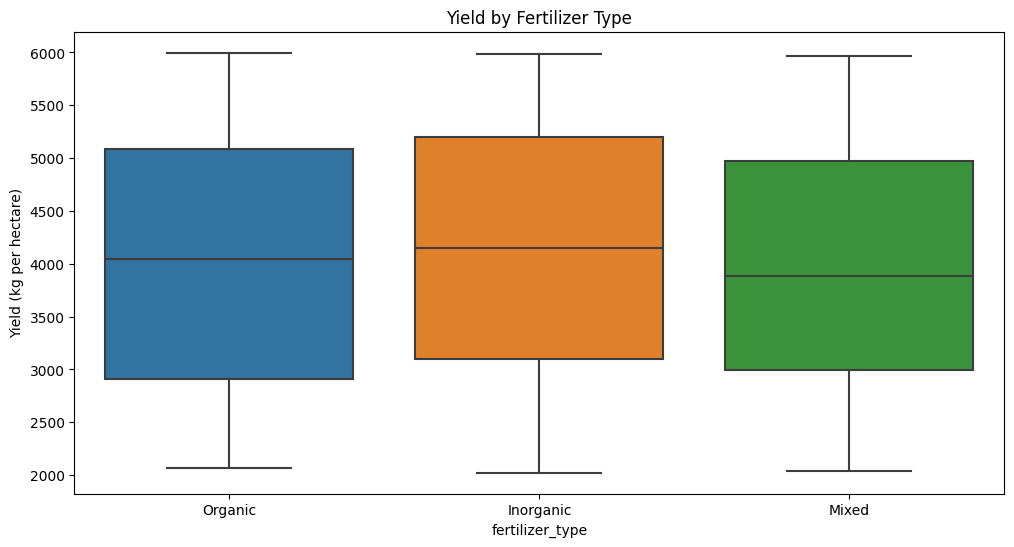

Yield by fertilizer type saved as 'yield_by_fertilizer.png'


In [8]:
# Step 6: Analyze impact of irrigation and fertilizer types
print("\nStep 6: Analyzing impact of irrigation and fertilizer types...")

# Irrigation type analysis
plt.figure(figsize=(12, 6))
sns.boxplot(x='irrigation_type', y='yield_kg_per_hectare', data=df)
plt.title('Yield by Irrigation Type')
plt.ylabel('Yield (kg per hectare)')
plt.savefig('yield_by_irrigation.png')
print("Yield by irrigation type saved as 'yield_by_irrigation.png'")

# Fertilizer type analysis
plt.figure(figsize=(12, 6))
sns.boxplot(x='fertilizer_type', y='yield_kg_per_hectare', data=df)
plt.title('Yield by Fertilizer Type')
plt.ylabel('Yield (kg per hectare)')
plt.show()
print("Yield by fertilizer type saved as 'yield_by_fertilizer.png'")


Step 7: Analyzing impact of crop disease status...


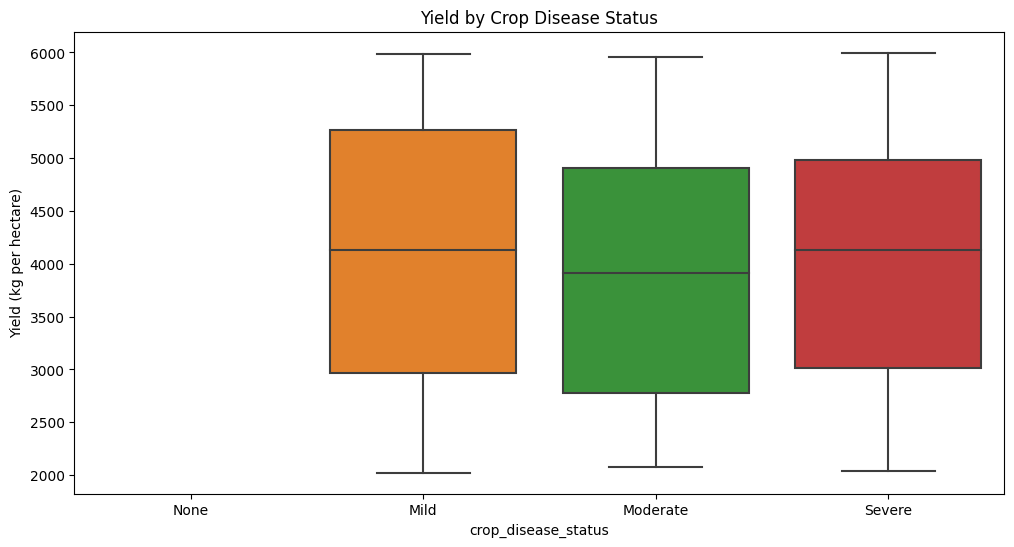

Yield by disease status saved as 'yield_by_disease.png'


In [9]:

# Step 7: Analyze impact of crop disease
print("\nStep 7: Analyzing impact of crop disease status...")
plt.figure(figsize=(12, 6))
sns.boxplot(x='crop_disease_status', y='yield_kg_per_hectare', data=df, 
            order=['None', 'Mild', 'Moderate', 'Severe'])
plt.title('Yield by Crop Disease Status')
plt.ylabel('Yield (kg per hectare)')
plt.show()
print("Yield by disease status saved as 'yield_by_disease.png'")

In [10]:

# Step 8: Prepare data for modeling
print("\nStep 8: Preparing data for predictive modeling...")

# Convert categorical variables to numeric using one-hot encoding
categorical_cols = ['region', 'crop_type', 'irrigation_type', 'fertilizer_type', 'crop_disease_status']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Select features and target
features = [col for col in df_encoded.columns if col not in ['yield_kg_per_hectare', 'farm_id', 'sensor_id', 
                                                             'sowing_date', 'harvest_date', 'timestamp']]
X = df_encoded[features]
y = df_encoded['yield_kg_per_hectare']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")


Step 8: Preparing data for predictive modeling...
Training set: 400 samples
Testing set: 100 samples


In [11]:

# Step 9: Build and evaluate Linear Regression model
print("\nStep 9: Building and evaluating Linear Regression model...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

lr_mse = mean_squared_error(y_test, lr_preds)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, lr_preds)

print(f"Linear Regression Results:")
print(f"MSE: {lr_mse:.2f}")
print(f"RMSE: {lr_rmse:.2f}")
print(f"R² Score: {lr_r2:.4f}")


Step 9: Building and evaluating Linear Regression model...
Linear Regression Results:
MSE: 1494142.00
RMSE: 1222.35
R² Score: -0.0819


In [12]:
# Step 10: Build and evaluate Random Forest model
print("\nStep 10: Building and evaluating Random Forest model...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_preds)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, rf_preds)

print(f"Random Forest Results:")
print(f"MSE: {rf_mse:.2f}")
print(f"RMSE: {rf_rmse:.2f}")
print(f"R² Score: {rf_r2:.4f}")


Step 10: Building and evaluating Random Forest model...
Random Forest Results:
MSE: 1469271.16
RMSE: 1212.13
R² Score: -0.0639



Step 11: Analyzing feature importance...
Top 10 most important features:
              Feature  Importance
6  pesticide_usage_ml    0.105059
9           longitude    0.094259
0     soil_moisture_%    0.090101
2       temperature_C    0.086649
3         rainfall_mm    0.086253
5      sunlight_hours    0.083143
4          humidity_%    0.079464
7          total_days    0.071370
8            latitude    0.068824
1             soil_pH    0.067657


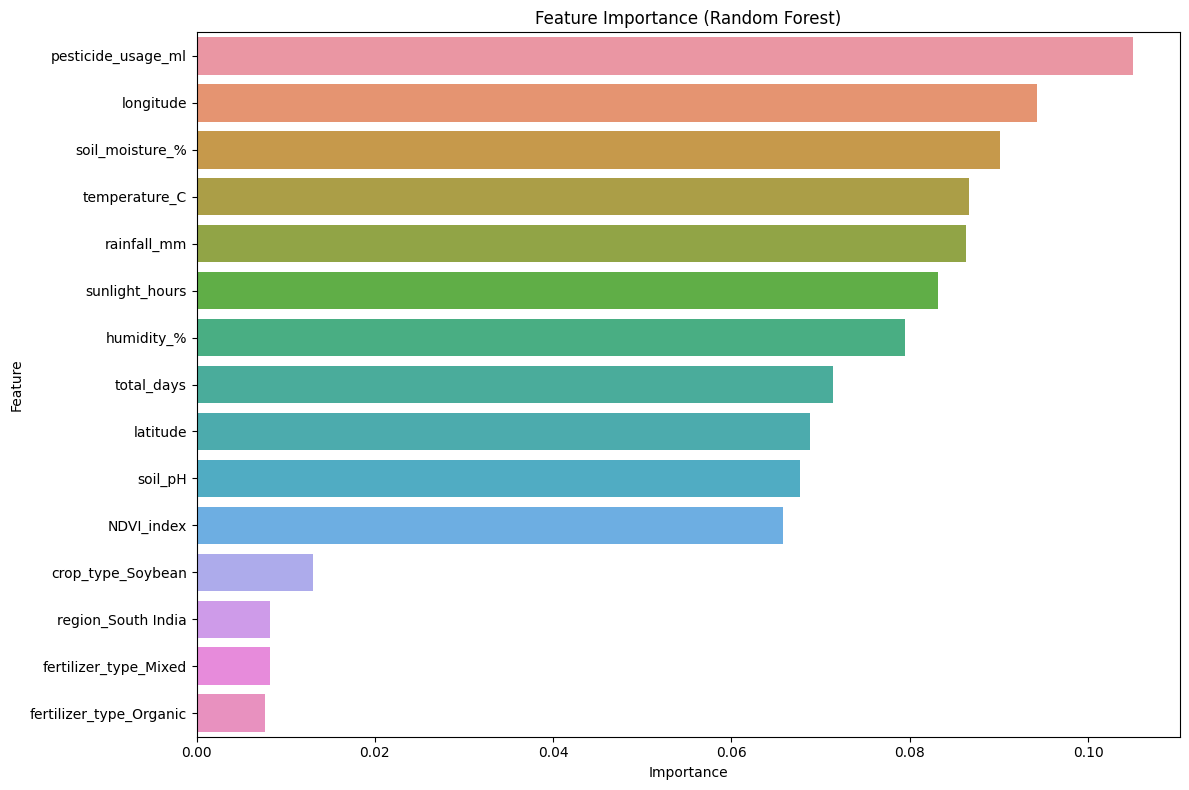

Feature importance plot saved as 'feature_importance.png'


In [13]:

# Step 11: Feature importance analysis (Random Forest)
print("\nStep 11: Analyzing feature importance...")
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})
feature_importance = feature_importance.sort_values('Importance', ascending=False)
print("Top 10 most important features:")
print(feature_importance.head(10))

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(15))
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()
print("Feature importance plot saved as 'feature_importance.png'")

In [14]:
# Step 12: Yield prediction by crop type and region
print("\nStep 12: Analyzing yield predictions by crop type and region...")

# Add predictions to the test dataset
test_df = df.iloc[X_test.index].copy()
test_df['predicted_yield'] = rf_preds

# Group by crop_type and region and find average actual vs predicted yield
crop_region_analysis = test_df.groupby(['crop_type', 'region']).agg({
    'yield_kg_per_hectare': 'mean',
    'predicted_yield': 'mean'
}).reset_index()

crop_region_analysis['prediction_error'] = ((crop_region_analysis['predicted_yield'] - 
                                           crop_region_analysis['yield_kg_per_hectare']) / 
                                           crop_region_analysis['yield_kg_per_hectare'] * 100)

print("Yield prediction analysis by crop type and region:")
print(crop_region_analysis)


Step 12: Analyzing yield predictions by crop type and region...
Yield prediction analysis by crop type and region:
   crop_type       region  yield_kg_per_hectare  predicted_yield  \
0     Cotton  Central USA           4325.172500      3754.301050   
1     Cotton  East Africa           3916.031667      3967.676667   
2     Cotton  North India           3406.803333      3939.736767   
3     Cotton  South India           2838.260000      3999.826100   
4     Cotton    South USA           3697.157500      3869.927625   
5      Maize  Central USA           5093.608000      4069.394740   
6      Maize  East Africa           2812.920000      3973.544857   
7      Maize  North India           3933.069000      3816.309450   
8      Maize  South India           3755.485000      3936.722550   
9      Maize    South USA           4757.887500      3881.470250   
10      Rice  Central USA           3414.942500      4070.676100   
11      Rice  East Africa           4630.891667      4025.239367   


In [15]:
# Step 13: Summary and Recommendations
print("\nStep 13: Summary and Recommendations")
print("===== Smart Farming Data Analysis Summary =====")
print(f"1. Dataset contains information on {df['farm_id'].nunique()} farms across {df['region'].nunique()} regions")
print(f"2. {df['crop_type'].nunique()} crop types are cultivated: {', '.join(df['crop_type'].unique())}")
print(f"3. The Random Forest model achieved an R² score of {rf_r2:.4f}, explaining {rf_r2*100:.1f}% of yield variation")
print(f"4. Most important factors affecting yield: {', '.join(feature_importance['Feature'].head(5))}")

# Find the best performing combinations
best_combos = crop_region_analysis.sort_values('yield_kg_per_hectare', ascending=False).head(3)
print("5. Best performing crop-region combinations:")
for _, row in best_combos.iterrows():
    print(f"   - {row['crop_type']} in {row['region']}: {row['yield_kg_per_hectare']:.2f} kg/hectare")




Step 13: Summary and Recommendations
===== Smart Farming Data Analysis Summary =====
1. Dataset contains information on 500 farms across 5 regions
2. 5 crop types are cultivated: Wheat, Soybean, Maize, Cotton, Rice
3. The Random Forest model achieved an R² score of -0.0639, explaining -6.4% of yield variation
4. Most important factors affecting yield: pesticide_usage_ml, longitude, soil_moisture_%, temperature_C, rainfall_mm
5. Best performing crop-region combinations:
   - Wheat in East Africa: 5393.05 kg/hectare
   - Maize in Central USA: 5093.61 kg/hectare
   - Maize in South USA: 4757.89 kg/hectare
